In [1]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

In [2]:
model = YOLO("yolov8n.pt")

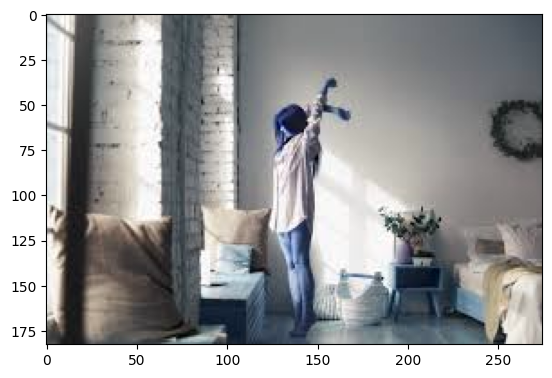

In [3]:
img = cv2.imread("image.jpg")
plt.imshow(img)

In [4]:
# Nhận diện
results = model(img)


0: 448x640 1 person, 1 chair, 1 potted plant, 1 vase, 82.8ms
Speed: 14.1ms preprocess, 82.8ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)


In [5]:
# Vẽ bounding box
for r in results:
    for box in r.boxes:
        cls = int(box.cls[0])
        if model.names[cls] == "person":
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
            cv2.putText(img, "Person", (x1, y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,255,0), 2)

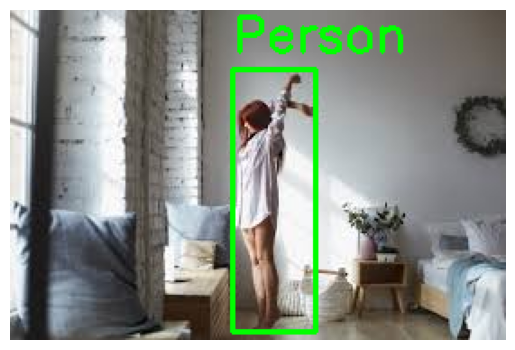

In [6]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis("off")
plt.show()